<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #4f46e5; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Lógica Proposicional y Agentes Basados en Conocimiento 🧠⚙️
      </h1>
      <p style="margin: 6px 0 0 0; color: #4f46e5; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Introducción a la Inteligencia Artificial
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #4f46e5; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 05 • Agentes de Conocimiento
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #4f46e5; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>


---
## 🎯 Objetivos de Aprendizaje

Este cuaderno abre el capítulo más orientado a **código** de todo el curso: los **Agentes Basados en Conocimiento**. Al finalizar podrás:

1. Explicar qué es un agente basado en conocimiento y cómo se diferencia de un agente reactivo simple.
2. Escribir sentencias de **lógica proposicional** usando símbolos y conectivos lógicos.
3. Entender qué es un **modelo** (mundo posible) y por qué una fórmula con $n$ símbolos tiene $2^n$ modelos posibles.
4. Comprender la relación de **implicación lógica** ($KB \models \alpha$) entre una base de conocimiento y una consulta.
5. Implementar y usar un motor de **verificación de modelos (model checking)** por fuerza bruta, en Python puro.

> 💻 Todo el código de este capítulo se apoya en la librería `logic.py`, construida desde cero (sin dependencias externas de lógica simbólica) y ubicada en la raíz de este módulo.


---
## 1. Agentes Basados en Conocimiento (1.17)

Un **agente basado en conocimiento** (*knowledge-based agent*) es un agente inteligente cuyo componente central es una **base de conocimiento (KB)**: un conjunto de sentencias, escritas en un **lenguaje de representación del conocimiento**, que describen hechos sobre el mundo.

El agente interactúa con su KB mediante dos operaciones fundamentales:

| Operación | Significado | Analogía |
|---|---|---|
| **TELL** | Agrega una nueva sentencia (percepción, hecho o regla) a la base de conocimiento. | Contarle al agente algo nuevo que observó. |
| **ASK** | Consulta a la base de conocimiento si una sentencia se puede inferir como verdadera. | Preguntarle al agente qué puede deducir. |

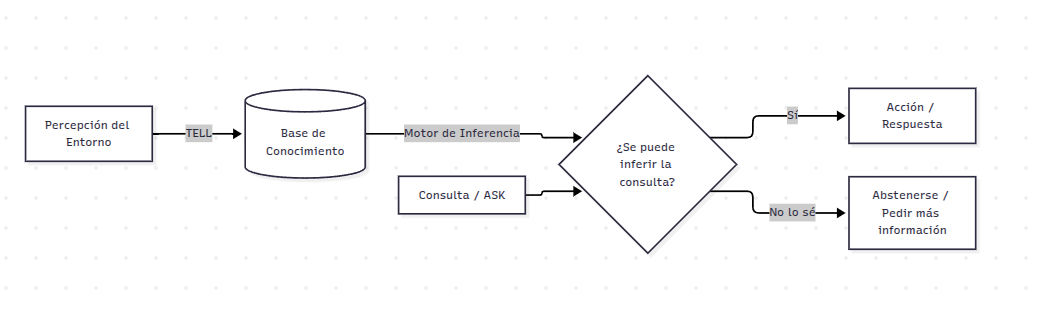

A diferencia de un agente puramente reactivo (tabla de reglas *condición → acción*), un agente basado en conocimiento puede **combinar hechos y reglas nuevas en tiempo real** para deducir información que nunca fue programada explícitamente. Esa capacidad de deducción es, precisamente, lo que estudiaremos en este capítulo usando **lógica proposicional**.


---
## 2. Lógica Proposicional: Lenguaje Formal del Conocimiento (1.17.1)

La **lógica proposicional** (o lógica de enunciados) es el lenguaje formal más simple para representar conocimiento. Su vocabulario consta de:

* **Símbolos proposicionales**: representan un hecho atómico que puede ser verdadero o falso (p. ej. `Lluvia`, `Paraguas`).
* **Conectivos lógicos**: combinan símbolos para formar sentencias más complejas.

| Conectivo | Símbolo | Nombre | Se lee | En `logic.py` |
|---|---|---|---|---|
| Negación | $\neg$ | NOT | "no P" | `Not(P)` |
| Conjunción | $\wedge$ | AND | "P y Q" | `And(P, Q)` |
| Disyunción | $\vee$ | OR | "P o Q" | `Or(P, Q)` |
| Implicación | $\rightarrow$ | IF-THEN | "si P entonces Q" | `Implication(P, Q)` |
| Bicondicional | $\leftrightarrow$ | IFF | "P si y solo si Q" | `Biconditional(P, Q)` |

En `logic.py` cada uno de estos conectivos es una **clase de Python** que representa un nodo de un árbol sintáctico. Toda sentencia (sea un símbolo simple o una combinación compleja) implementa dos métodos clave:

* `.evaluate(model)`: evalúa la sentencia bajo un modelo (diccionario `{símbolo: bool}`) y devuelve `True` o `False`.
* `.formula()`: devuelve la representación textual en notación infija de la sentencia.


In [ ]:
import sys, os

# Nos aseguramos de que Python pueda encontrar logic.py en esta misma carpeta.
sys.path.append(os.getcwd())

from logic import Symbol, Not, And, Or, Implication, Biconditional, model_check

# --- Símbolos proposicionales -----------------------------------------
Lluvia = Symbol("Lluvia")
Paraguas = Symbol("Paraguas")
Frio = Symbol("Frio")

# --- Sentencias compuestas ------------------------------------------------
s1 = Implication(Lluvia, Paraguas)                 # Si llueve, entonces llevo paraguas.
s2 = And(Lluvia, Frio)                              # Llueve y hace frío.
s3 = Biconditional(Paraguas, Or(Lluvia, Frio))      # Llevo paraguas si y solo si llueve o hace frío.
s4 = Not(And(Lluvia, Not(Paraguas)))                # No es cierto que llueva y no lleve paraguas.

for nombre, s in [("s1", s1), ("s2", s2), ("s3", s3), ("s4", s4)]:
    print(f"{nombre}: {s.formula()}   |  símbolos involucrados: {sorted(s.symbols())}")


---
## 3. Modelos y Mundos Posibles (1.17.2)

Un **modelo** (o *mundo posible*) es una asignación completa de valores de verdad (`True`/`False`) a todos los símbolos proposicionales relevantes. Si una sentencia involucra $n$ símbolos distintos, existen exactamente $2^n$ modelos posibles, porque cada símbolo puede tomar 2 valores de forma independiente.

Por ejemplo, para los símbolos `Lluvia` y `Paraguas` ($n=2$), hay $2^2 = 4$ mundos posibles:

| Lluvia | Paraguas | ¿Lluvia → Paraguas? |
|---|---|---|
| Falso | Falso | Verdadero |
| Falso | Verdadero | Verdadero |
| Verdadero | Falso | **Falso** |
| Verdadero | Verdadero | Verdadero |

Nota que la implicación **solo es falsa** en el mundo donde llueve y NO se lleva paraguas: ese es el único mundo que contradice la regla.


In [ ]:
from logic import enumerate_models

# Generamos y evaluamos TODOS los mundos posibles para la implicación Lluvia -> Paraguas.
formula = Implication(Lluvia, Paraguas)
simbolos = formula.symbols()

print(f"Símbolos involucrados: {sorted(simbolos)}  ->  2^{len(simbolos)} = {2**len(simbolos)} modelos posibles\n")

for modelo in enumerate_models(simbolos):
    valor = formula.evaluate(modelo)
    print(f"  Modelo {modelo}  ->  {formula.formula()} = {valor}")


---
## 4. Base de Conocimiento e Inferencia (1.17.3)

Una **base de conocimiento (KB)** es, en la práctica, la **conjunción (AND)** de todas las sentencias que el agente considera verdaderas. Formalmente, decimos que:

$$KB \models \alpha$$

("$KB$ **implica lógicamente** $\alpha$", o "$\alpha$ **se infiere de** $KB$") si y solo si **en todo modelo donde $KB$ es verdadera, $\alpha$ también lo es**.

Esta es la definición matemática exacta de lo que hace la operación `ASK`: preguntar si una consulta $\alpha$ es una consecuencia lógica necesaria de todo lo que el agente sabe.

Construyamos una pequeña base de conocimiento y evaluémosla bajo un modelo específico:


In [ ]:
# Base de conocimiento: combinamos varias sentencias con And (TELL múltiple).
knowledge = And(
    Implication(Lluvia, Paraguas),   # Regla: si llueve, llevo paraguas.
    Lluvia                            # Hecho observado: hoy llueve.
)

print(f"Base de conocimiento: {knowledge.formula()}\n")

# Evaluamos la KB bajo dos modelos distintos (dos "mundos" candidatos).
modelo_A = {"Lluvia": True, "Paraguas": True}
modelo_B = {"Lluvia": True, "Paraguas": False}

for nombre, modelo in [("A", modelo_A), ("B", modelo_B)]:
    print(f"Modelo {nombre} = {modelo}  ->  KB.evaluate() = {knowledge.evaluate(modelo)}")


Observa que la base de conocimiento es verdadera **solo** en el Modelo A. Eso es justo lo que necesitamos: si logramos demostrar que `Paraguas` es verdadera en **todos** los modelos donde la KB es verdadera (en este caso, el único es el Modelo A, y allí `Paraguas = True`), entonces podemos afirmar con certeza que $KB \models Paraguas$.

---
## 5. Verificación de Modelos — *Model Checking* (1.17.4)

El algoritmo más simple (aunque no el más eficiente) para decidir si $KB \models \alpha$ se llama **verificación de modelos por fuerza bruta**: enumerar **todos** los $2^n$ modelos posibles y comprobar la condición de implicación en cada uno.

```mermaid
flowchart TD
    A[Símbolos de KB y consulta] --> B{"¿Quedan símbolos\nsin asignar?"}
    B -- Sí --> C["Tomar un símbolo p:\ngenerar modelo con p=True\ny modelo con p=False"]
    C --> B
    B -- No: modelo completo --> D{"¿KB es verdadera\nen este modelo?"}
    D -- No --> E["Vacuamente cierto:\nno contradice la implicación"]
    D -- Sí --> F{"¿La consulta también\nes verdadera aquí?"}
    F -- Sí --> G["Este modelo no refuta KB ⊨ consulta"]
    F -- No --> H["Contraejemplo encontrado:\nKB NO implica la consulta"]
```

Esta es exactamente la lógica que implementa `model_check(knowledge, query)` en `logic.py`, de forma recursiva: en cada paso fija un símbolo en `True` y en `False`, y solo cuando ya asignó **todos** los símbolos evalúa la condición final.


In [ ]:
# ASK: ¿la base de conocimiento implica que debo llevar paraguas?
resultado = model_check(knowledge, Paraguas)
print(f"¿KB ⊨ Paraguas?  ->  {resultado}")

# ASK: ¿la base de conocimiento implica que NO llueve? (debería ser falso, ya que Lluvia es un hecho)
resultado2 = model_check(knowledge, Not(Lluvia))
print(f"¿KB ⊨ ¬Lluvia?   ->  {resultado2}")

# ASK: ¿la base de conocimiento implica que hace frío? (no tenemos ninguna regla sobre el frío)
resultado3 = model_check(knowledge, Frio)
print(f"¿KB ⊨ Frio?      ->  {resultado3}")


Nota algo importante: `model_check(knowledge, Frio)` devuelve `False`, pero eso **no** significa que "hace frío es falso". Significa que **no hay evidencia suficiente en la KB** para afirmar con certeza que hace frío. La lógica proposicional distingue con precisión entre *"se puede demostrar que es falso"* y *"no se puede demostrar que sea verdadero"* — una distinción crucial para cualquier agente que razone bajo incertidumbre.

---
## 6. Hacia Agentes Basados en Conocimiento (1.17.5)

Con `Symbol`, los conectivos lógicos y `model_check`, ya tenemos todas las piezas para ensamblar un agente basado en conocimiento minimalista: un objeto que **acumula sentencias con TELL** y **responde preguntas con ASK**, apoyándose en `model_check` como motor de inferencia.


In [ ]:
class AgenteDeConocimiento:
    """Agente basado en conocimiento minimalista: TELL acumula sentencias,
    ASK consulta por inferencia usando model_check."""

    def __init__(self):
        self._sentencias = []

    def tell(self, sentencia):
        """Agrega una nueva sentencia (hecho o regla) a la base de conocimiento."""
        self._sentencias.append(sentencia)

    def base_de_conocimiento(self):
        """Devuelve la conjunción (AND) de todas las sentencias acumuladas."""
        if not self._sentencias:
            raise ValueError("La base de conocimiento está vacía.")
        return And(*self._sentencias) if len(self._sentencias) > 1 else self._sentencias[0]

    def ask(self, consulta):
        """Responde si la consulta se puede inferir de la base de conocimiento."""
        return model_check(self.base_de_conocimiento(), consulta)


# --- Pequeño escenario: agente de soporte técnico ------------------------
TicketUrgente = Symbol("TicketUrgente")
FueraDeHorario = Symbol("FueraDeHorario")
Escalar = Symbol("Escalar")

agente = AgenteDeConocimiento()
agente.tell(Implication(And(TicketUrgente, FueraDeHorario), Escalar))  # Regla de escalamiento.
agente.tell(TicketUrgente)                                              # Percepción: el ticket es urgente.
agente.tell(FueraDeHorario)                                             # Percepción: es fuera de horario.

print(f"KB del agente: {agente.base_de_conocimiento().formula()}\n")
print(f"ASK -> ¿Se debe escalar el ticket?  {agente.ask(Escalar)}")


---
## Resumen / Puntos Clave

* Un **agente basado en conocimiento** separa lo que "sabe" (la KB) de cómo lo usa (el motor de inferencia), mediante las operaciones `TELL` y `ASK`.
* La **lógica proposicional** representa el conocimiento con símbolos atómicos y cinco conectivos: $\neg$, $\wedge$, $\vee$, $\rightarrow$, $\leftrightarrow$.
* Un **modelo** es una asignación de verdad a todos los símbolos; una fórmula con $n$ símbolos tiene $2^n$ modelos posibles.
* $KB \models \alpha$ (implicación lógica) significa que $\alpha$ es verdadera en **todo** modelo donde $KB$ es verdadera — esa es la definición formal de "poder inferir" algo.
* **Model checking** por fuerza bruta decide $KB \models \alpha$ enumerando los $2^n$ modelos; es correcto pero exponencial, lo que motivará algoritmos más eficientes (resolución, encadenamiento) en el siguiente cuaderno.
* La librería `logic.py`, construida enteramente en Python puro, ya nos permite ensamblar un agente funcional con `TELL` y `ASK`.

### 🧠 Autoevaluación

1. ¿Por qué `model_check(knowledge, Frio)` devuelve `False` en el ejemplo del agente del clima, si en realidad no sabemos si hace frío o no? Explica la diferencia entre "se infiere falso" y "no se puede inferir verdadero".
2. Si una base de conocimiento involucra 8 símbolos proposicionales distintos, ¿cuántos modelos debe enumerar `model_check` en el peor caso? ¿Qué ocurre si la base de conocimiento crece a 30 símbolos?
3. Diseña tú mismo una pequeña base de conocimiento (con `And`, `Or`, `Not`, `Implication` o `Biconditional`) sobre un escenario de tu interés, y formula dos consultas: una que se pueda inferir como verdadera y otra que no se pueda inferir con la información disponible.
4. ¿Qué diferencia existe entre un agente puramente reactivo (tabla condición-acción) y el `AgenteDeConocimiento` implementado en este cuaderno? ¿En qué situaciones reales preferirías uno sobre el otro?
